---

# 16. Independent student task — Diabetes regression

Now apply the same workflow to a different modality.

We use the scikit-learn **Diabetes** dataset.

The dataset contains baseline physiological measurements from patients and a quantitative target representing disease progression.

Your task is to prepare, fit, diagnose, and evaluate linear regression models without following step-by-step commands from the guided section.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import dcor
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml, load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

RANDOM_STATE = 170926

In [2]:
diabetes = load_diabetes(as_frame=True)

diabetes_df = diabetes.frame.copy()
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [4]:
diabetes_df.shape

(442, 11)

In [5]:
diabetes_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


## Student research question

> **Can baseline physiological measurements predict quantitative diabetes disease progression?**

## Required tasks

### A. Data presentation

Identify:

- one observation;
- target variable;
- predictor variables;
- dimensionality of the dataset.

### B. Descriptive analysis

- summarize the target;
- visualize its distribution;
- visualize at least three predictor–target relationships.

### C. Correlation

- calculate Pearson correlations;
- identify the predictor most strongly correlated with the target;
- compare at least one Pearson and Spearman result.

### D. Simple regression

Choose one predictor and fit:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

Report and interpret:

- intercept;
- slope.

### E. Residual diagnostics

Produce:

- observed vs predicted plot;
- residuals vs fitted plot;
- residual histogram;
- Q-Q plot.

Discuss:

- linearity;
- homoscedasticity;
- residual normality.

### F. Multiple regression

Fit a model using all available predictors.

Inspect:

- coefficients;
- predictor correlations;
- possible multicollinearity.

### G. Train/test evaluation

Create a train/test split and report:

- MAE;
- MSE;
- RMSE;
- $R^2$.

Compare simple and multiple regression on **test data**.

### H. Interpretation

Write a short Markdown conclusion answering:

1. Which model generalized better?
2. Did adding more variables help?
3. Are any regression assumptions questionable?
4. Are coefficient interpretations straightforward?
5. What is one important limitation of the dataset or model?

In [ ]:
## Features from https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset
# age age in years
# sex
# bmi body mass index
# bp average blood pressure
# s1 tc, total serum cholesterol
# s2 ldl, low-density lipoproteins
# s3 hdl, high-density lipoproteins
# s4 tch, total cholesterol / HDL
# s5 ltg, possibly log of serum triglycerides level
# s6 glu, blood sugar level

In [11]:
## Data presentation
## Identify 1 observation
print(f'One observation \n {diabetes_df.iloc[0]}')
print('==========================================')
## Target var
target_col = 'target'
target_df = diabetes_df[target_col]
print(f'Target var \n {target_df.head(3)}')
print('==========================================')
## Predictors
predictor_cols = diabetes_df.columns[:-1]
predictor_df = diabetes_df[predictor_cols]
print(f'Predictors \n {predictor_cols} \n {predictor_df.head(3)}')
print('==========================================')
## Dimentionality
print(f'Dimentionality: {len(predictor_cols)} features; {diabetes_df.shape[0]} observations')

One observation 
 age         0.038076
sex         0.050680
bmi         0.061696
bp          0.021872
s1         -0.044223
s2         -0.034821
s3         -0.043401
s4         -0.002592
s5          0.019907
s6         -0.017646
target    151.000000
Name: 0, dtype: float64
Target var 
 0    151.0
1     75.0
2    141.0
Name: target, dtype: float64
Predictors 
 Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='str') 
         age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
Dimentionality: 10 features; 442 observations


In [12]:
## Descriptive analysis
diabetes_df[target_col].describe()

count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

In [13]:
import seaborn as sns

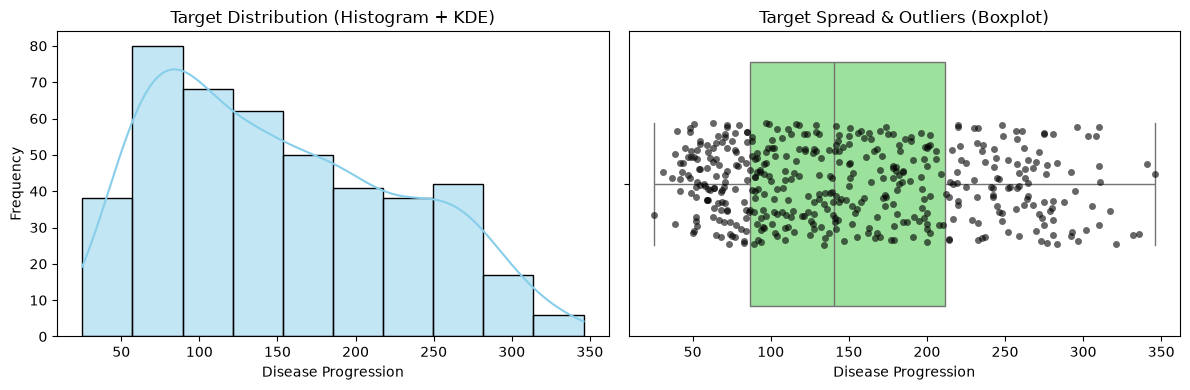

In [22]:
## Visualize target distribution. Hist + KDE, boxplot

## !!! AI
# Create a figure with a Histogram/KDE and a Boxplot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Histogram + KDE
sns.histplot(diabetes_df[target_col], kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Target Distribution (Histogram + KDE)')
axes[0].set_xlabel('Disease Progression')
axes[0].set_ylabel('Frequency')

# 2. Boxplot
sns.boxplot(x=diabetes_df[target_col], ax=axes[1], color='lightgreen')

# 2. Overlay the individual points
sns.stripplot(
    x=diabetes_df[target_col], 
    ax=axes[1], 
    color='black',    # Color of the points
    alpha=0.6,        # Transparency so overlapping points are visible
    jitter=0.2        # Spreads points horizontally to avoid overlapping into a single line
)

axes[1].set_title('Target Spread & Outliers (Boxplot)')
axes[1].set_xlabel('Disease Progression')

plt.tight_layout()
plt.show()

The probablilty density function is moderately right-skewed; Most observations have target value of 70-150

Boxblot did not reveal outliers, values seem to have approximately constant density across values within box.
Looks like the dataset was preliminarily cleaned from severe outliers (whiskers probably served as cutoffs) 

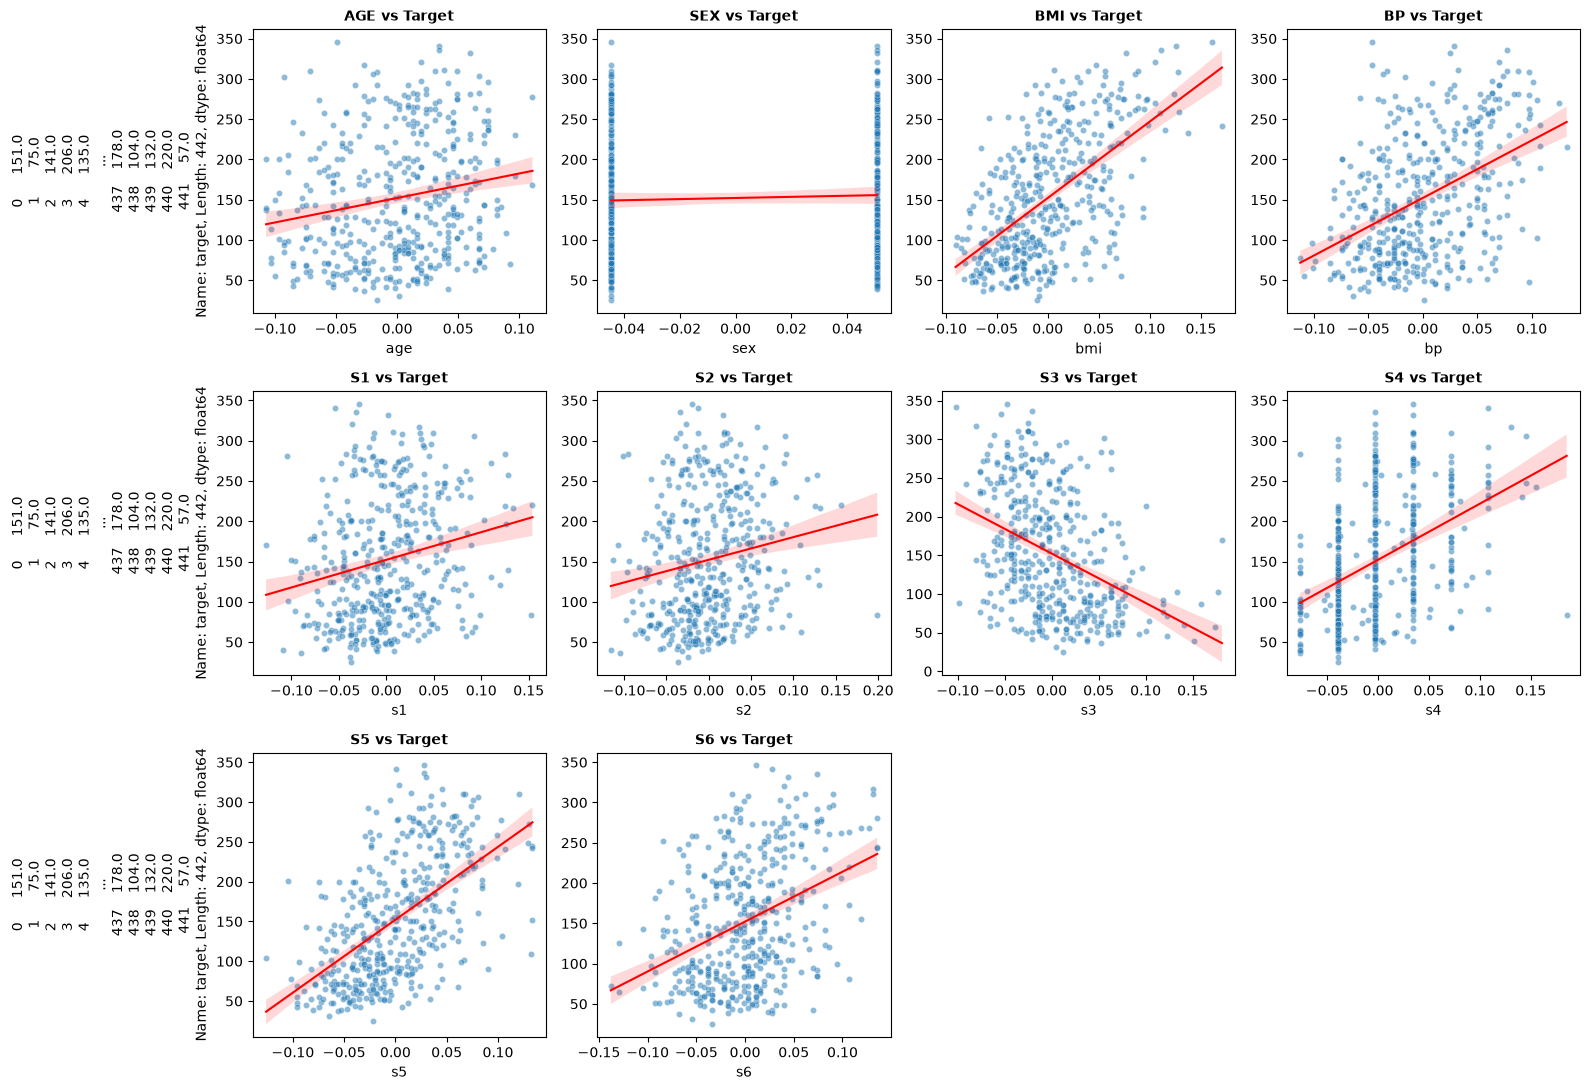

In [23]:
## Predictor-target relationships
## As there are not so many predictors, I decide to visualize all of them

target_var = diabetes_df[target_col]

# Create a 3x4 grid of subplots
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes_flat = axes.flatten()

# Loop through all 10 features
for i, feat in enumerate(predictor_cols):
    ax = axes_flat[i]
    sns.scatterplot(data=diabetes_df, x=feat, y=target_var, ax=ax, alpha=0.5, s=20)
    sns.regplot(data=diabetes_df, x=feat, y=target_var, ax=ax, scatter=False, color='red', line_kws={'linewidth': 1.5})
    ax.set_title(f"{feat.upper()} vs Target", fontsize=10, fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel(target_var if i % 4 == 0 else "") # Only label y-axis on left edge for cleanliness

# Hide the 2 unused extra subplots in the 3x4 grid
for j in range(len(predictor_cols), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()

BMI and S5 seem to have strongest close to linear relationshtp with target

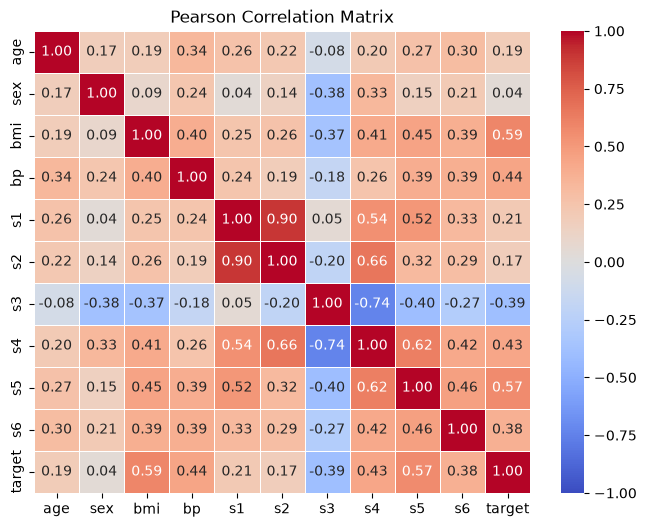

In [39]:
## Correlation

pearson_corr = diabetes_df.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(
    pearson_corr,
    annot=True,  # Displays the correlation coefficient value inside each cell
    cmap='coolwarm',  # Color map (blue = negative, red = positive)
    fmt='.2f',  # Format numbers to 2 decimal places
    vmin=-1,
    vmax=1,  # Fixes the color scale from -1 to 1
    linewidths=0.5,  # Adds grid lines between cells
)

plt.title('Pearson Correlation Matrix')
plt.show()

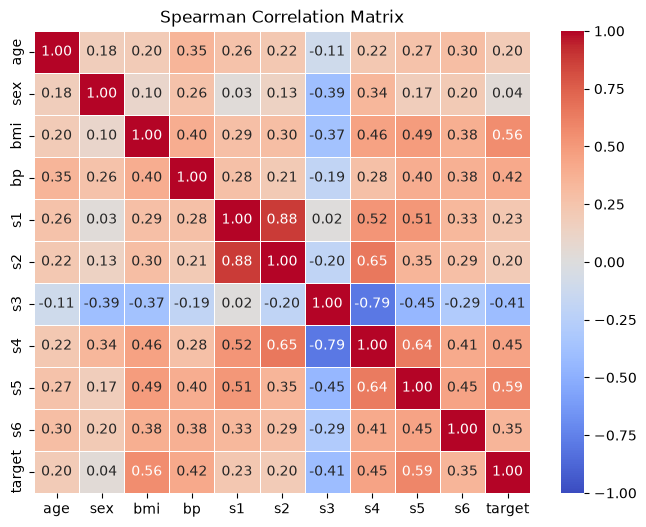

In [40]:
spearman_corr = diabetes_df.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(
    spearman_corr,
    annot=True,  # Displays the correlation coefficient value inside each cell
    cmap='coolwarm',  # Color map (blue = negative, red = positive)
    fmt='.2f',  # Format numbers to 2 decimal places
    vmin=-1,
    vmax=1,  # Fixes the color scale from -1 to 1
    linewidths=0.5,  # Adds grid lines between cells
)

plt.title('Spearman Correlation Matrix')
plt.show()

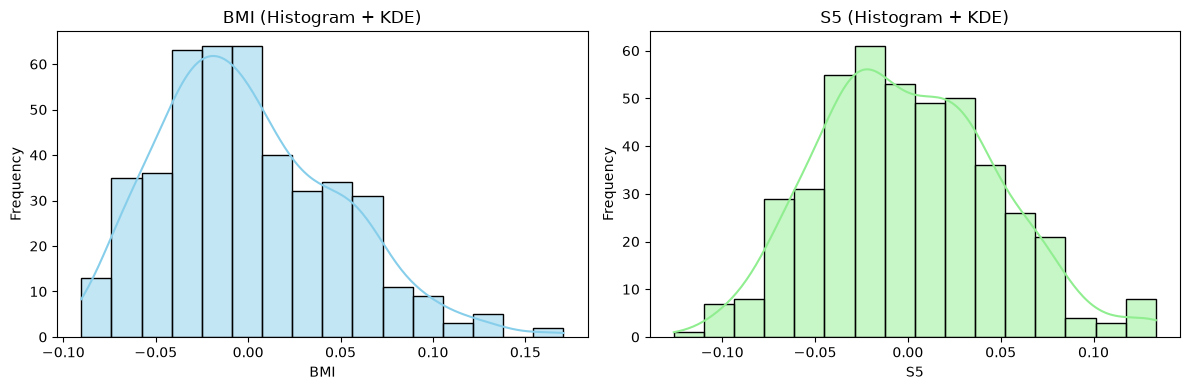

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Histogram + KDE
sns.histplot(diabetes_df['bmi'], kde=True, ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('BMI (Histogram + KDE)')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Frequency')


sns.histplot(x=diabetes_df['s5'], kde=True, ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('S5 (Histogram + KDE)')
axes[1].set_xlabel('S5')
axes[1].set_ylabel('Frequency')


plt.tight_layout()
plt.show()

Top Pearson - BMI (0.59)

Top Spearman - s5 (0.59)

The top correlated fetures results slightly differ across methods, despite correlation coefficients for top fetures are close. Although distributions are not perfectly normal (neither target nor BMI and S5), I decide to stick to Pearson top correlated feature, as this method highlights specifically strongest linear correlation, while Spearman measures monotonic correlation, which is not necessarily linear. Top Speraman correlation is S5, which is also top 2 Pearson feature. The fact S5 has higher coefficient in Spearman and lower in Pearson may indicate less linearity and/or normality.

In [48]:
## Simple Regression

X_simple = diabetes_df[['bmi']]
y = diabetes_df['target']

simple_model = LinearRegression()
simple_model.fit(X_simple, y)


print(f"Intercept (beta_0): {simple_model.intercept_}")
print(f"Slope (beta_1):     {simple_model.coef_[0]}\n")

Intercept (beta_0): 152.13348416289617
Slope (beta_1):     949.4352603840387



Intercept, 152 - expected disease progression value when predictor (BMI) is zero, meaning average.

Slope is large, 949, indicating strong positive correlation with disease progression, strong per-unit change.

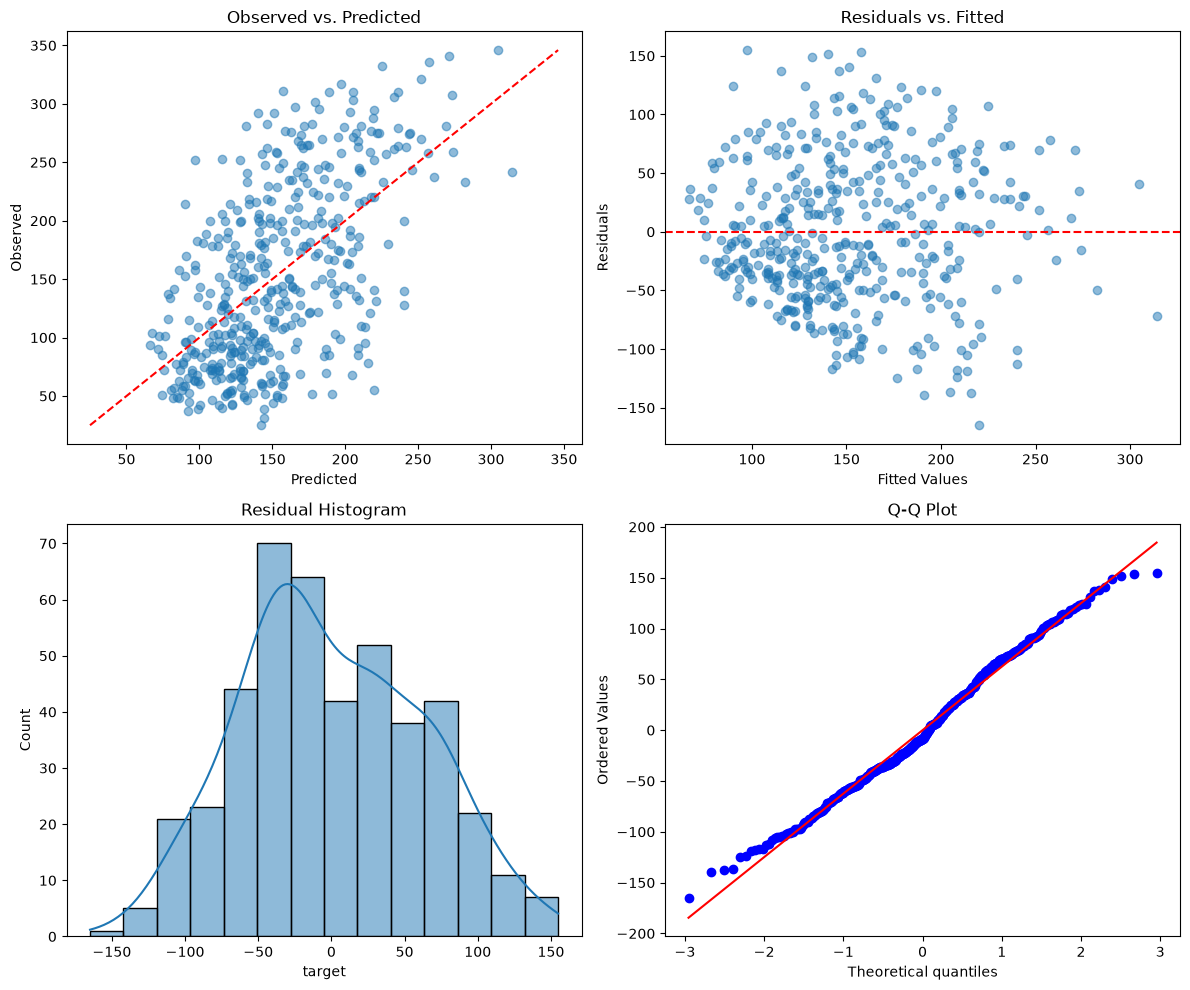

In [49]:
## Residual diagnostics

y_pred_simple = simple_model.predict(X_simple)
residuals = y - y_pred_simple

## AI

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Observed vs Predicted
axes[0, 0].scatter(y_pred_simple, y, alpha=0.5)
axes[0, 0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
axes[0, 0].set_xlabel("Predicted")
axes[0, 0].set_ylabel("Observed")
axes[0, 0].set_title("Observed vs. Predicted")

# Residuals vs Fitted
axes[0, 1].scatter(y_pred_simple, residuals, alpha=0.5)
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel("Fitted Values")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].set_title("Residuals vs. Fitted")

# Residual Histogram
sns.histplot(residuals, kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Residual Histogram")

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

Predictions are not perfect, but center around red line, as expected. Residuals are homoscedastic and follow apploxinately normal distributions with slightly heavy tails, as displayed on KDE and Q-Q plot.

In [50]:
## Multiple Regression
X_multi = diabetes_df[predictor_cols]
multi_model = LinearRegression()
multi_model.fit(X_multi, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](10,)","[ -10.01,-239.82, 519.85,..., 177.06, 751.27, 67.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](10,)","['age','sex','bmi',...,'s4','s5','s6']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,152.1
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,10


In [51]:
coef_df = pd.DataFrame({"Feature": predictor_cols, "Coefficient": multi_model.coef_})

print("Multiple Regression Coefficients:")
print(coef_df.to_string(index=False), "\n")

Multiple Regression Coefficients:
Feature  Coefficient
    age   -10.009866
    sex  -239.815644
    bmi   519.845920
     bp   324.384646
     s1  -792.175639
     s2   476.739021
     s3   101.043268
     s4   177.063238
     s5   751.273700
     s6    67.626692 



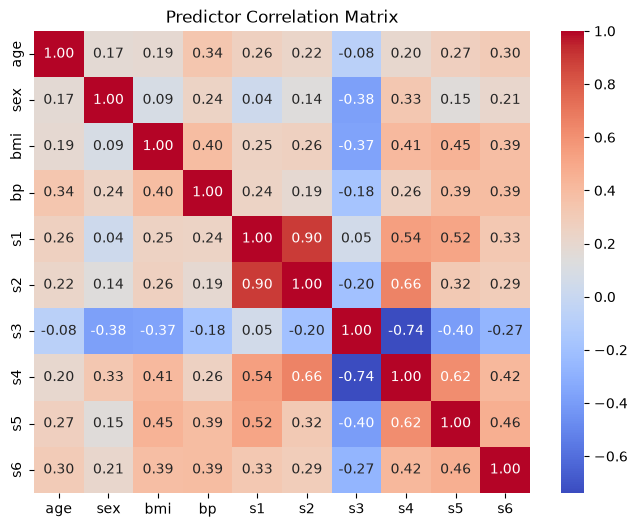

In [52]:
plt.figure(figsize=(8, 6))
sns.heatmap(X_multi.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Predictor Correlation Matrix")
plt.show()

In [53]:
# Train/test evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# Fit Simple on Train
simple_eval = LinearRegression()
simple_eval.fit(X_train[['bmi']], y_train)
y_pred_simple_test = simple_eval.predict(X_test[['bmi']])

# Fit Multiple on Train
multi_eval = LinearRegression()
multi_eval.fit(X_train, y_train)
y_pred_multi_test = multi_eval.predict(X_test)

In [55]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

metrics_simple = evaluate(y_test, y_pred_simple_test)
metrics_multi = evaluate(y_test, y_pred_multi_test)

eval_df = pd.DataFrame(
    [metrics_simple, metrics_multi],
    columns=["MAE", "MSE", "RMSE", "R2"],
    index=["Simple Regression", "Multiple Regression"]
)

print(eval_df)

                           MAE          MSE       RMSE        R2
Simple Regression    52.259976  4061.825928  63.732456  0.233350
Multiple Regression  42.794095  2900.193628  53.853446  0.452603
